In [1]:
import torch

In [2]:
torch.cuda.is_available()

True

In [3]:
torch.cuda.get_device_name(0)

'Tesla T4'

In [4]:
!pip install ultralytics yt-dlp -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.8/183.8 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 33.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 73.2 MB/s eta 0:00:00


In [5]:
!pip install timm -q

In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [7]:
midas = torch.hub.load("intel-isl/MiDaS", "MiDaS_small")
midas.to("cuda")
midas.eval()

The repository intel-isl_MiDaS does not belong to the list of trusted repositories and as such cannot be downloaded. Do you trust this repository and wish to add it to the trusted list of repositories (y/N)?y
Downloading: "https://github.com/intel-isl/MiDaS/zipball/master" to /root/.cache/torch/hub/master.zip


/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


Loading weights:  None
The repository rwightman_gen-efficientnet-pytorch does not belong to the list of trusted repositories and as such cannot be downloaded. Do you trust this repository and wish to add it to the trusted list of repositories (y/N)?y
Downloading: "https://github.com/rwightman/gen-efficientnet-pytorch/zipball/master" to /root/.cache/torch/hub/master.zip
Downloading: "https://github.com/rwightman/pytorch-image-models/releases/download/v0.1-weights/tf_efficientnet_lite3-b733e338.pth" to /root/.cache/torch/hub/checkpoints/tf_efficientnet_lite3-b733e338.pth
Downloading: "https://github.com/isl-org/MiDaS/releases/download/v2_1/midas_v21_small_256.pt" to /root/.cache/torch/hub/checkpoints/midas_v21_small_256.pt


100%|██████████| 81.8M/81.8M [00:00<00:00, 133MB/s]


MidasNet_small(
  (pretrained): Module(
    (layer1): Sequential(
      (0): Conv2dSameExport(3, 32, kernel_size=(3, 3), stride=(2, 2), bias=False)
      (1): BatchNorm2d(32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
      (3): Sequential(
        (0): DepthwiseSeparableConv(
          (conv_dw): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (bn1): BatchNorm2d(32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
          (act1): ReLU6(inplace=True)
          (se): Identity()
          (conv_pw): Conv2d(32, 24, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn2): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
          (act2): Identity()
        )
      )
      (4): Sequential(
        (0): InvertedResidual(
          (conv_pw): Conv2d(24, 144, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): BatchNorm2d(144,

In [8]:
midas_transforms = torch.hub.load("intel-isl/MiDaS", "transforms")
transform = midas_transforms.small_transform

Using cache found in /root/.cache/torch/hub/intel-isl_MiDaS_master


In [11]:
cap = cv2.VideoCapture("traffic.mp4")
ret, frame =cap.read()
cap.release()

In [12]:
img_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
inp_batch = transform(img_rgb).to("cuda")

In [13]:
with torch.no_grad():
  prediction = midas(inp_batch)
  prediction = torch.nn.functional.interpolate(
      prediction.unsqueeze(1),
      size = img_rgb.shape[:2],
      mode = "bicubic",
      align_corners = False
  ).squeeze()
depth_map = prediction.cpu().numpy()
print("Depth map shape:", depth_map.shape)
print("Min depth value:", depth_map.min())
print("Max depth value:", depth_map.max())

Depth map shape: (720, 1280)
Min depth value: 19.72607
Max depth value: 922.62396


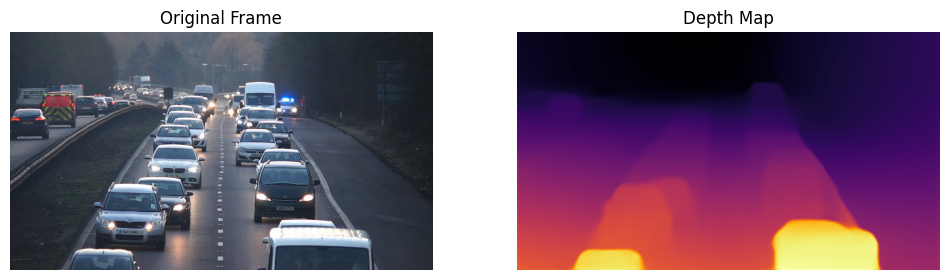

In [14]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(img_rgb)
plt.title("Original Frame")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(depth_map, cmap="inferno")
plt.title("Depth Map")
plt.axis("off")

plt.show()